# Permanent water sub-model - Notebook 5

* **Products used:** 
[cgls_landcover](https://explorer.digitalearth.africa/products/cgls_landcover)

## Background

This notebook calculates and stores the fifth sub-model in the elephant Habitat Suitability Model; the permanent water sub-model. It has a single permanent water layer.

The notebook executes the following steps:

   1. Load landcover CGLS data and select the permanent water layer.
   2. Within the area of interest, calculate distance to permanent water quantified as euclidean distance in metres.
   3. Standardise the euclidean distance measure so it ranges between 0 and 1.
   4. Save the results as a sub-model.

### Load packages
Import Python packages that are used for the analysis.

In [1]:
%matplotlib inline

import datacube
import numpy as np
import xarray as xr
from deafrica_tools.plotting import plot_lulc

try:
      import xrspatial
except:
      !pip install xrspatial
    
from xrspatial import proximity

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [2]:
dc = datacube.Datacube(app='Elephant-HSM-pw')

## Load CGLS landcover

Spatial parameters must be the same as other notebooks. This is ensured by using the stored query from earlier notebooks.

In [3]:
%store -r query

ds_cgls = dc.load(product='cgls_landcover', **query).squeeze()

## Visualise location of permanent water

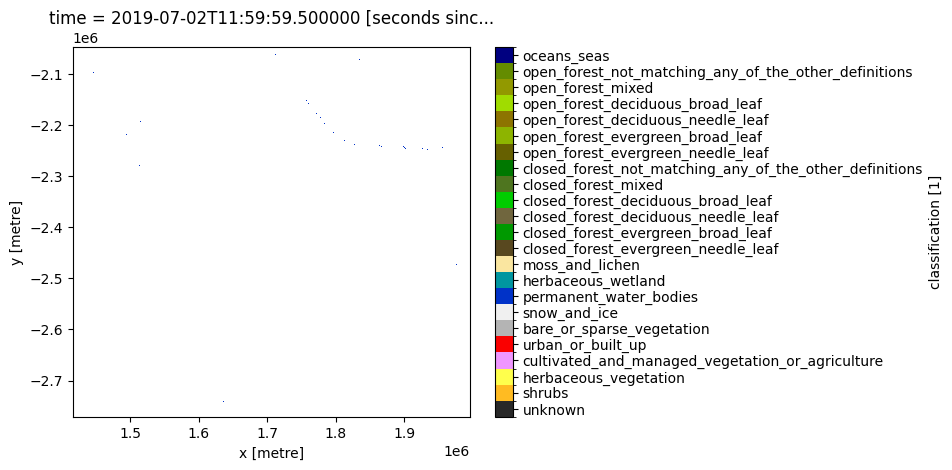

In [4]:
plot_lulc(ds_cgls.where(ds_cgls==80)['classification'], product="CGLS", legend=True)

The below cell calculates euclidean distance and standardises from 0-1, noting that permanent water is considered a positive habitat attribute so values close to `1` are on permanent water.

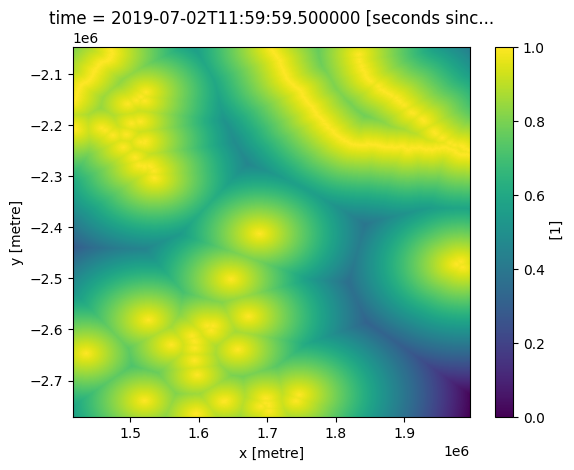

In [5]:
cgls_pw = ds_cgls.where(ds_cgls==80)

proximity_pw = proximity(cgls_pw.classification, distance_metric = 'EUCLIDEAN')

pw_proximity_std = 1 - (proximity_pw/np.max(proximity_pw))
pw_proximity_std = pw_proximity_std.fillna(0)
pw_proximity_std.plot()

## Save to outputs

As this sub-model comprises only a single layer, we can save the result to the outputs folder.

In [6]:
pw_model = pw_proximity_std.drop('time', dim=None)
pw_model.attrs = {}
pw_model.to_netcdf('outputs/pw_sm.nc')

/tmp/ipykernel_2384/601149859.py:1: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  pw_model = pw_proximity_std.drop('time', dim=None)


---

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Slack channel](http://slack.opendatacube.org/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

**Compatible datacube version:**

In [7]:
print(datacube.__version__)

1.9.13


**Last Tested:**

In [8]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-08-28'